PySpark installation

In [1]:
!pip install pyspark

Checking if we have java - not needed later

In [1]:
import subprocess
result = subprocess.run(["java", "-version"], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)


openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment Temurin-17.0.18+8 (build 17.0.18+8)
OpenJDK 64-Bit Server VM Temurin-17.0.18+8 (build 17.0.18+8, mixed mode, sharing)



Checking the java path - not needed later

In [2]:
import subprocess
result = subprocess.run(["where", "java"], capture_output=True, text=True)
print(result.stdout) # the result will indicate what path you should use in the next code block 

C:\Program Files\Eclipse Adoptium\jdk-17.0.18.8-hotspot\bin\java.exe



## Initialization of Spark

In [1]:
# the next 2 lines are needed everytime we want to use PySpark
import os
import sys

os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-17.0.18.8-hotspot" # change to your path
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"

print("PYSPARK_PYTHON:", os.environ["PYSPARK_PYTHON"])
print("Python version:", sys.version)

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("MaterialsDataPipeline") \
    .config("spark.driver.host", "127.0.0.1") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .getOrCreate()

print("Spark version:", spark.version)
print("Spark session created.")

PYSPARK_PYTHON: C:\Users\jagod\anaconda3\envs\pyspark_env\python.exe
Python version: 3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]
Spark version: 3.5.3
Spark session created.


In [4]:
!pip install mp-api

## Downloading materials data

In [2]:
from mp_api.client import MPRester
import pandas as pd

API_KEY = "YOUR_KEY" # here paste your key from Materials Project

# Downloading materials data from Materials Project
with MPRester(API_KEY) as mpr:
    results = mpr.materials.summary.search(
        fields=["material_id", "formula_pretty", "band_gap", 
                "density", "volume", "nsites", "nelements",
                "formation_energy_per_atom", "energy_above_hull"],
        num_chunks=50  # 50 000 records
    )

print(f"Downloaded records: {len(results)}")

Retrieving SummaryDoc documents:   0%|          | 0/50000 [00:00<?, ?it/s]

Downloaded records: 50000


__Transforming data into DataFrame__

In [3]:
# Converting results to Pandas DataFrame
df_pandas = pd.DataFrame([{
    "material_id": str(r.material_id),
    "formula": r.formula_pretty,
    "band_gap": r.band_gap,
    "density": r.density,
    "volume": r.volume,
    "nsites": r.nsites,
    "nelements": r.nelements,
    "formation_energy_per_atom": r.formation_energy_per_atom,
    "energy_above_hull": r.energy_above_hull
} for r in results])

print(f"Pandas DataFrame shape: {df_pandas.shape}")
df_pandas.head()

Pandas DataFrame shape: (50000, 9)


,material_id,formula,band_gap,density,volume,nsites,nelements,formation_energy_per_atom,energy_above_hull
0,mp-1197903,C,0.0797,1.030997,1547.569425,80,1,1.410500,1.410500
1,mp-1094120,Nb,0.0000,8.161256,226.839615,12,1,0.189748,0.189748
2,mp-1179802,Rb,0.0000,1.525036,744.494598,8,1,0.053649,0.053649
3,mp-1244933,Si,0.0000,2.599954,1793.764938,100,1,0.349291,0.349291
4,mp-1244964,C,0.0724,1.769793,1126.924923,100,1,0.934597,0.934597


### Loading data into PySpark

In [4]:
# Converting Pandas DataFrame to PySpark DataFrame
df_spark = spark.createDataFrame(df_pandas)

# Checking the schema (column types)
print("Schema:")
df_spark.printSchema()

print(f"\nNumber of rows: {df_spark.count()}")

Schema:
root
 |-- material_id: string (nullable = true)
 |-- formula: string (nullable = true)
 |-- band_gap: double (nullable = true)
 |-- density: double (nullable = true)
 |-- volume: double (nullable = true)
 |-- nsites: long (nullable = true)
 |-- nelements: long (nullable = true)
 |-- formation_energy_per_atom: double (nullable = true)
 |-- energy_above_hull: double (nullable = true)


Number of rows: 50000


### Previewing data

In [6]:
# in PySpark we use .show() instead of .head()
df_spark.show(5)

+-----------+-------+-------------------+-----------------+------------------+------+---------+-------------------------+--------------------+
|material_id|formula|           band_gap|          density|            volume|nsites|nelements|formation_energy_per_atom|   energy_above_hull|
+-----------+-------+-------------------+-----------------+------------------+------+---------+-------------------------+--------------------+
| mp-1197903|      C|0.07970000000000001|1.030996672490697|1547.5694249833693|    80|        1|       1.4104997176249991|  1.4104997176249991|
| mp-1094120|     Nb|                0.0|8.161255619756384|226.83961495276392|    12|        1|      0.18974828500000201| 0.18974828500000002|
| mp-1179802|     Rb|                0.0|1.525035869723976| 744.4945979508938|     8|        1|     0.053649282500000006|0.053649282500000006|
| mp-1244933|     Si|                0.0|2.599954373928591|1793.7649376717561|   100|        1|      0.34929145859999905| 0.34929145859999905|

### Statistics

In [7]:
# Basic statistics - equivalent of df.describe() in Pandas
df_spark.describe().show()

+-------+-----------+-------+------------------+------------------+------------------+------------------+------------------+-------------------------+-------------------+
|summary|material_id|formula|          band_gap|           density|            volume|            nsites|         nelements|formation_energy_per_atom|  energy_above_hull|
+-------+-----------+-------+------------------+------------------+------------------+------------------+------------------+-------------------------+-------------------+
|  count|      50000|  50000|             50000|             50000|             50000|             50000|             50000|                    50000|              50000|
|   mean|       NULL|    NaN|0.7286639847794802| 5.965872697934079|405.97031011528065|          20.84652|           2.55134|       -0.996261289256523|0.15483210362959068|
| stddev|       NULL|    NaN|1.3776751952248525|3.2243737332332607| 590.5678305714306|24.245687471317847|0.5298394275593127|       1.128396645556

### Filtering, grouping and Spark SQL

In [8]:
from pyspark.sql import functions as F

# Filtering - only non-metals (band_gap > 0)
df_nonmetals = df_spark.filter(df_spark["band_gap"] > 0)
print(f"Non-metals: {df_nonmetals.count()}")

# Filtering - only stable materials (energy_above_hull == 0)
df_stable = df_spark.filter(df_spark["energy_above_hull"] == 0)
print(f"Stable materials: {df_stable.count()}")

# Grouping - average band_gap by number of elements
df_spark.groupBy("nelements") \
    .agg(
        F.count("material_id").alias("count"),
        F.round(F.avg("band_gap"), 4).alias("avg_band_gap"),
        F.round(F.avg("density"), 4).alias("avg_density")
    ) \
    .orderBy("nelements") \
    .show()

Non-metals: 18608
Stable materials: 13502
+---------+-----+------------+-----------+
|nelements|count|avg_band_gap|avg_density|
+---------+-----+------------+-----------+
|        1|  834|      0.7145|     5.6701|
|        2|20765|      0.4464|     6.6035|
|        3|28401|      0.9355|     5.5084|
+---------+-----+------------+-----------+



In [9]:
# Registering DataFrame as a temporary SQL table
df_spark.createOrReplaceTempView("materials")

# Spark SQL query - same as the groupBy above but in SQL
result = spark.sql("""
    SELECT 
        nelements,
        COUNT(material_id) AS count,
        ROUND(AVG(band_gap), 4) AS avg_band_gap,
        ROUND(AVG(density), 4) AS avg_density,
        ROUND(AVG(formation_energy_per_atom), 4) AS avg_formation_energy
    FROM materials
    GROUP BY nelements
    ORDER BY nelements
""")

result.show()

+---------+-----+------------+-----------+--------------------+
|nelements|count|avg_band_gap|avg_density|avg_formation_energy|
+---------+-----+------------+-----------+--------------------+
|        1|  834|      0.7145|     5.6701|              0.2807|
|        2|20765|      0.4464|     6.6035|             -0.5356|
|        3|28401|      0.9355|     5.5084|             -1.3705|
+---------+-----+------------+-----------+--------------------+



In [10]:
# Advanced Spark SQL query - finding best candidates for semiconductors
# (band_gap between 0.5 and 3.0 eV - optimal range for solar cells)
# only stable materials (energy_above_hull == 0)
semiconductor_candidates = spark.sql("""
    SELECT 
        nelements,
        COUNT(material_id) AS count,
        ROUND(AVG(band_gap), 4) AS avg_band_gap,
        ROUND(MIN(band_gap), 4) AS min_band_gap,
        ROUND(MAX(band_gap), 4) AS max_band_gap,
        ROUND(AVG(density), 4) AS avg_density
    FROM materials
    WHERE band_gap BETWEEN 0.5 AND 3.0 AND energy_above_hull = 0
    GROUP BY nelements
    ORDER BY count DESC
""")

semiconductor_candidates.show()

+---------+-----+------------+------------+------------+-----------+
|nelements|count|avg_band_gap|min_band_gap|max_band_gap|avg_density|
+---------+-----+------------+------------+------------+-----------+
|        3| 2305|      1.6928|      0.5011|      2.9983|     4.9173|
|        2|  648|       1.475|      0.5057|      2.9866|     4.7768|
|        1|   14|      1.7214|      0.6105|      2.8979|     2.8264|
+---------+-----+------------+------------+------------+-----------+



## Performance comparison: PySpark vs Pandas

In [11]:
import time

# Operation: groupBy + aggregation on 50000 rows

# PySpark
start = time.time()
df_spark.groupBy("nelements") \
    .agg(F.avg("band_gap"), F.avg("density"), F.avg("formation_energy_per_atom")) \
    .collect()
pyspark_time = time.time() - start
print(f"PySpark time: {pyspark_time:.3f} seconds")

# Pandas
start = time.time()
df_pandas.groupby("nelements") \
    .agg({"band_gap": "mean", "density": "mean", "formation_energy_per_atom": "mean"})
pandas_time = time.time() - start
print(f"Pandas time: {pandas_time:.3f} seconds")

print(f"\nOn 50 000 rows Pandas is {pyspark_time/pandas_time:.1f}x faster")

PySpark time: 24.881 seconds
Pandas time: 0.014 seconds

On 50 000 rows Pandas is 1840.9x faster
Note: PySpark overhead dominates on small datasets.
PySpark advantage grows significantly with millions of rows.


PySpark overhead dominates on small datasets.
PySpark advantage grows significantly with millions of rows.

__Saving results to CSV__

In [13]:
# saving results to CSV - standard step in data pipeline
semiconductor_candidates.toPandas().to_csv("semiconductor_candidates.csv", index=False)
print("Results saved to CSV.")

# saving full dataset
df_pandas.to_csv("materials_50k.csv", index=False)
print("Full dataset saved to CSV.")

Results saved to CSV.
Full dataset saved to CSV.


## Visualization of results

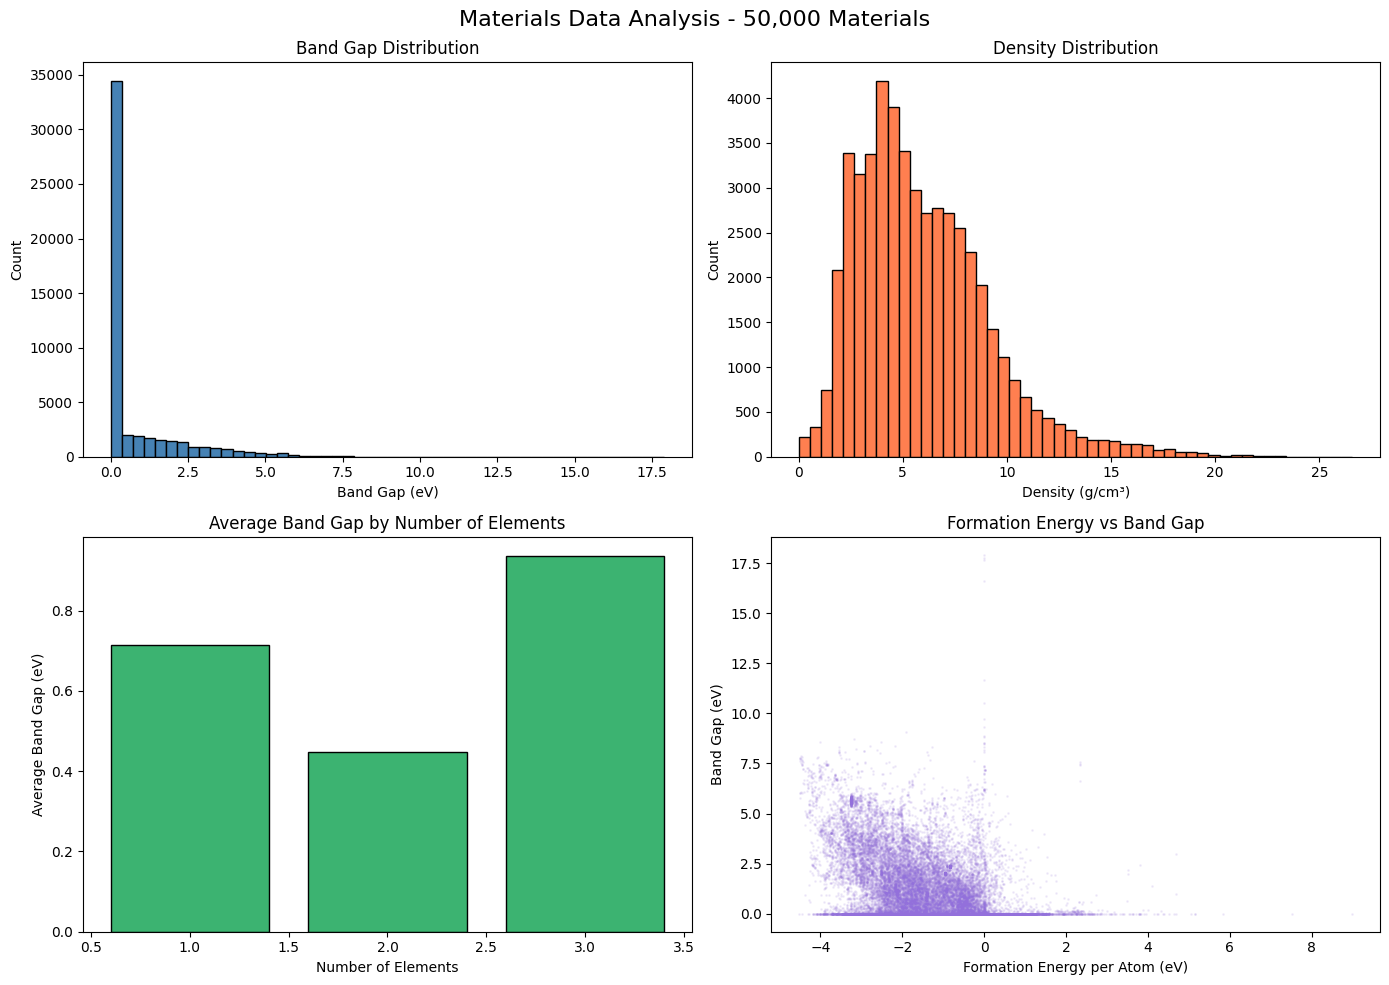

In [14]:
import matplotlib.pyplot as plt

# Converting Spark results to Pandas for visualization
df_viz = df_spark.select(
    "band_gap", "density", "nelements", 
    "formation_energy_per_atom", "energy_above_hull"
).toPandas()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Materials Data Analysis - 50,000 Materials", fontsize=16)

# Band gap distribution
axes[0, 0].hist(df_viz["band_gap"], bins=50, color="steelblue", edgecolor="black")
axes[0, 0].set_title("Band Gap Distribution")
axes[0, 0].set_xlabel("Band Gap (eV)")
axes[0, 0].set_ylabel("Count")

# Density distribution
axes[0, 1].hist(df_viz["density"], bins=50, color="coral", edgecolor="black")
axes[0, 1].set_title("Density Distribution")
axes[0, 1].set_xlabel("Density (g/cm³)")
axes[0, 1].set_ylabel("Count")

# Average band gap by number of elements
nelements_data = df_viz.groupby("nelements")["band_gap"].mean()
axes[1, 0].bar(nelements_data.index, nelements_data.values, 
               color="mediumseagreen", edgecolor="black")
axes[1, 0].set_title("Average Band Gap by Number of Elements")
axes[1, 0].set_xlabel("Number of Elements")
axes[1, 0].set_ylabel("Average Band Gap (eV)")

# Formation energy vs band gap
axes[1, 1].scatter(df_viz["formation_energy_per_atom"], df_viz["band_gap"],
                   alpha=0.1, color="mediumpurple", s=1)
axes[1, 1].set_title("Formation Energy vs Band Gap")
axes[1, 1].set_xlabel("Formation Energy per Atom (eV)")
axes[1, 1].set_ylabel("Band Gap (eV)")

plt.tight_layout()
plt.show()

## Pipeline Summary

1. **Data Ingestion** - downloaded 50,000 materials from Materials Project API
2. **PySpark Setup** - created SparkSession, loaded data into Spark DataFrame
3. **Exploratory Analysis** - basic statistics, schema inspection
4. **Filtering** - identified 18,608 non-metals and 13,502 stable materials
5. **Spark SQL** - queried semiconductor candidates (band gap 0.5-3.0 eV) for solar cell applications
6. **Performance Comparison** - PySpark vs Pandas on 50,000 rows
7. **Data Export** - saved results to CSV
8. **Visualization** - distributions and correlations

**Key Finding:** 2,967 stable semiconductor candidates identified with optimal band gap for solar cell applications.